# Styling and Plot Types

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

```{contents}
:local:
:depth: 2
```


```{index} plot controls
```
## Plot Controls and Methods

This section focuses on controlling the visible appearance of a figure and Axes.


```{index} subplots parameters
```
### `subplots()` Parameters



| Parameter | Type | Default | What It Controls | Example |
| --- | --- | --- | --- | --- |
| `nrows` | int | 1 | Number of subplot rows | `plt.subplots(2, 1)` |
| `ncols` | int | 1 | Number of subplot columns | `plt.subplots(1, 3)` |
| `figsize` | tuple | None | Figure size `(width, height)` in inches | `figsize=(8, 4)` |
| `dpi` | int | rcParams value | Resolution in dots per inch | `dpi=150` |
| `sharex` | bool or str | False | Share x-axis between subplots | `sharex=True` |
| `sharey` | bool or str | False | Share y-axis between subplots | `sharey='row'` |
| `squeeze` | bool | True | Return a scalar vs array of axes when possible | `squeeze=False` |

For a longer reference, see [matplotlib.pyplot.subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html).


```{index} figure methods
```
### Figure-Level Controls

In contrast to `ax` methods, figure-level methods act on the **whole figure** rather than on a single axes. They are especially useful for overall sizing, layout, titles, and exporting.

| Method | What it sets |
|---|---|
| **`fig.suptitle('title')`** | Master title over all subplots |
| **`fig.tight_layout()`** | Auto-fix subplot spacing |
| `fig.set_size_inches(w, h)` | Figure size |
| `fig.savefig('file.png')` | Save to file (also `.pdf`, `.svg`, etc.) |
| `fig.set_dpi(150)` | Resolution |
| `fig.subplots_adjust(...)` | Manual spacing (`hspace`, `wspace`, `left`, `right`, ...) |
| `fig.colorbar(mappable, ax=ax)` | Add a colorbar tied to an axes |


```{index} axes methods
```
### Axes Formatting Methods

After creating a figure and axes, the next step is usually formatting. These methods do not change the underlying data; they control how the plot is labeled, styled, and displayed.

| Method | What it sets |
|---|---|
| **`ax.plot(x, y, 'r')`** | Plot data (format string: color + linestyle + marker) |
| **`ax.set_xlabel('label')`** | X-axis label |
| **`ax.set_ylabel('label')`** | Y-axis label |
| **`ax.set_title('title')`** | Title above the plot |
| **`ax.legend()`** | Add a legend to that axes |
| `ax.set_xlim(min, max)` | X-axis range |
| `ax.set_ylim(min, max)` | Y-axis range |
| `ax.grid(True)` | Toggle grid |


```{index} plot parameters, line width (linewidth)
```
### `ax.plot()` Parameters

| Parameter | Type | Default | What It Controls | Example |
| --- | --- | --- | --- | --- |
| `x`, `y` | array-like | — | Data to plot | `ax.plot(x, y)` |
| `color` | str or tuple | auto | Line color | `color='red'` |
| `linewidth` / `lw` | float | 1.5 | Thickness of the line | `lw=2` |
| `linestyle` / `ls` | str | `'-'` | Line style | `ls='--'` |
| `marker` | str | `None` | Marker shape at each data point | `marker='o'` |
| `markersize` / `ms` | float | 6 | Marker size | `ms=8` |
| `markerfacecolor` / `mfc` | str | auto | Fill color of markers | `mfc='white'` |
| `markeredgecolor` / `mec` | str | auto | Edge color of markers | `mec='black'` |
| `alpha` | float | 1.0 | Transparency (0 = invisible, 1 = opaque) | `alpha=0.7` |
| `label` | str | `None` | Legend label for the line | `label='Series A'` |
| `zorder` | float | auto | Drawing order (higher = on top) | `zorder=5` |

Common `linestyle` values: `'-'` (solid), `'--'` (dashed), `'-.'` (dash-dot), `':'` (dotted).  
Common `marker` values: `'o'` (circle), `'s'` (square), `'^'` (triangle), `'x'` (cross), `'+'` (plus), `'.'` (point).

For a full reference, see [matplotlib.axes.Axes.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html).



```{index} styling charts
```
## Styling in Practice

```{index} rcParams, style sheet (plt.style.use)
```
### `rcParams`

A **style sheet** is a named set of appearance settings: colors, fonts, grid lines, and so on. `plt.style.use('ggplot')` switches the style for every chart drawn afterward, and `plt.style.available` lists the styles installed in your environment. To try a style on one chart without changing the rest of the notebook, wrap the plotting code in `with plt.style.context(...):`.

The same bar chart in two styles:

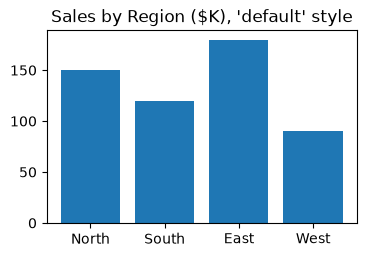

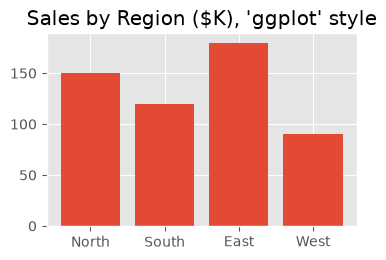

In [2]:
regions = ['North', 'South', 'East', 'West']
sales = [150, 120, 180, 90]                        ### quarterly sales in $K

for style in ['default', 'ggplot']:
    with plt.style.context(style):                 ### the style applies only inside this block
        fig, ax = plt.subplots(figsize=(4, 2.5))
        ax.bar(regions, sales)
        ax.set_title(f"Sales by Region ($K), '{style}' style")
        plt.show()

Each individual setting lives in `plt.rcParams`, a dictionary of defaults such as `'font.size'` or `'axes.grid'`. Setting `plt.rcParams['font.size'] = 13` changes every chart drawn afterward; `plt.rc_context()` applies settings to one block only, which keeps the rest of the notebook unchanged.

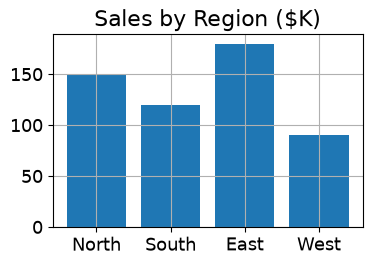

In [3]:
regions = ['North', 'South', 'East', 'West']
sales = [150, 120, 180, 90]

### plt.rcParams['font.size'] = 13 would change every later chart;
### plt.rc_context() changes it only inside this block
with plt.rc_context({'font.size': 13, 'axes.grid': True}):
    fig, ax = plt.subplots(figsize=(4, 2.5))
    ax.bar(regions, sales)
    ax.set_title('Sales by Region ($K)')
    plt.show()

```{index} legend
```
### Legends for Axes



Legends are attached to an **axes** in the OO API. You typically supply `label=...` when plotting, then call `ax.legend()` to display the legend for that axes.


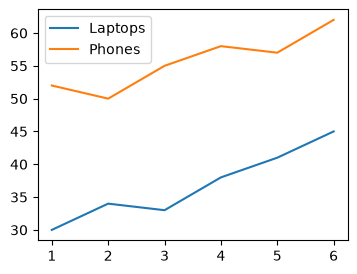

In [4]:
month = np.arange(1, 7)
laptops = np.array([30, 34, 33, 38, 41, 45])          ### units sold
phones = np.array([52, 50, 55, 58, 57, 62])

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(month, laptops, label="Laptops")   ### label= is what the legend shows
ax.plot(month, phones, label="Phones")
ax.legend()
plt.show()


If the legend overlaps the plotted data, pass a `loc=` argument to `ax.legend()` to move it.

Common values include string labels such as `'best'`, `'upper right'`, `'upper left'`, `'lower left'`, and `'lower right'`.


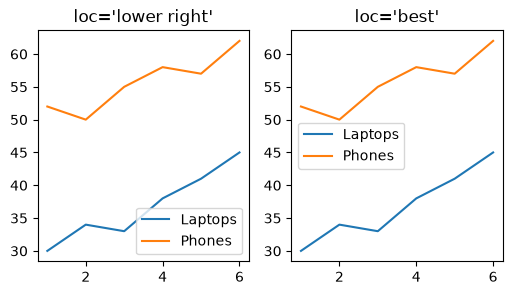

In [5]:
month = np.arange(1, 7)
laptops = np.array([30, 34, 33, 38, 41, 45])          ### units sold
phones = np.array([52, 50, 55, 58, 57, 62])

fig, ax = plt.subplots(1, 2, figsize=(6, 3))

ax[0].plot(month, laptops, label="Laptops")
ax[0].plot(month, phones, label="Phones")
ax[0].legend(loc='lower right')
ax[0].set_title("loc='lower right'")

ax[1].plot(month, laptops, label="Laptops")
ax[1].plot(month, phones, label="Phones")
ax[1].legend(loc='best')
ax[1].set_title("loc='best'")
plt.show()

```{index} axis range (set_xlim and set_ylim)
```
### Plot Range `set_xlim(), set_ylim()`

You can set axis ranges directly with `ax.set_xlim(...)` and `ax.set_ylim(...)`. The three charts below plot the same daily sales:

- **Default range:** Matplotlib fits the axes to the data, so the y-axis starts near 38, not 0.
- **Start at zero:** with `set_ylim(0, 80)`, the promotion spike looks like the rise it really is: the peak of about \$75K is nearly 80% above a normal day of about \$42K.
- **Zoomed in:** `set_xlim(14, 22)` and `set_ylim(30, 80)` show only the promotion week.

Axis ranges change what the reader sees, not the data. A y-axis that does not start at zero can make small differences look large, which matters most for bar charts.

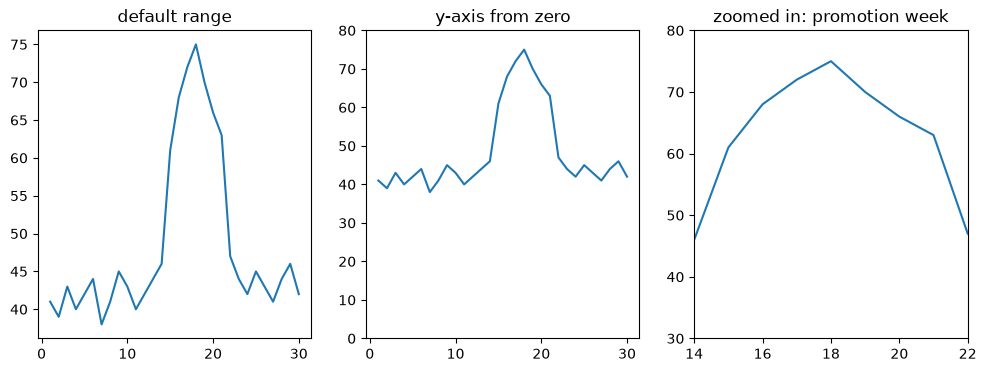

In [6]:
day = np.arange(1, 31)                  ### days in June
daily_sales = np.array([41, 39, 43, 40, 42, 44, 38, 41, 45, 43,
                        40, 42, 44, 46, 61, 68, 72, 75, 70, 66,
                        63, 47, 44, 42, 45, 43, 41, 44, 46, 42])   ### $K; promotion on days 15-21

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(day, daily_sales)
axes[0].set_title("default range")

axes[1].plot(day, daily_sales)
axes[1].set_ylim(0, 80)          # y-axis starts at zero
axes[1].set_title("y-axis from zero")

axes[2].plot(day, daily_sales)
axes[2].set_ylim(30, 80)         # y-axis runs from 30 to 80
axes[2].set_xlim(14, 22)         # x-axis runs from day 14 to day 22
axes[2].set_title("zoomed in: promotion week")
plt.show()

In [7]:
### Exercise: Controlling Axis Ranges
#   1. Create month = np.arange(1, 13),
#      this_year = np.array([110, 104, 118, 121, 125, 119, 130, 128, 135, 150, 168, 190]), and
#      last_year = np.array([98, 95, 104, 108, 112, 110, 117, 115, 121, 133, 150, 171]).
#   2. Use fig, axes = plt.subplots(1, 2, figsize=(10, 4)).
#   3. On axes[0], plot month vs this_year and month vs last_year. Set title "Full Year".
#   4. On axes[1], plot the same data, then set:
#      - x-axis limits to [1, 6] using set_xlim
#      - y-axis limits to [80, 140] using set_ylim
#      Set title "First Half".
#   5. Call plt.tight_layout() at the end.
### Your code starts here.




### Your code ends here.

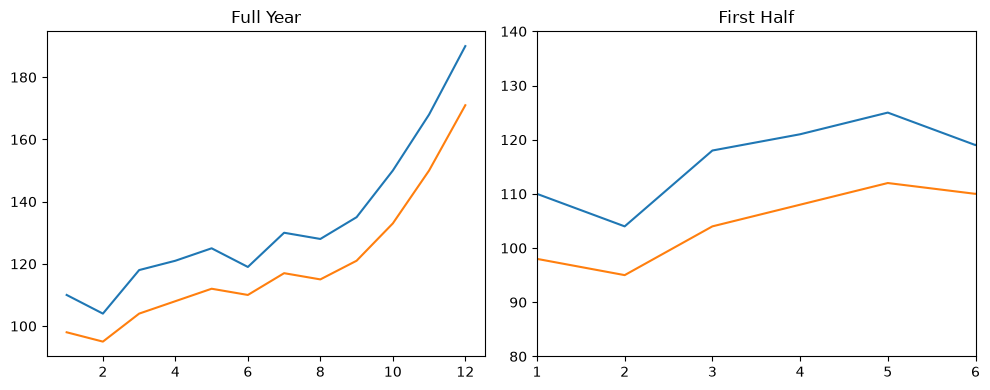

In [8]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

month = np.arange(1, 13)
this_year = np.array([110, 104, 118, 121, 125, 119, 130, 128, 135, 150, 168, 190])
last_year = np.array([98, 95, 104, 108, 112, 110, 117, 115, 121, 133, 150, 171])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(month, this_year)
axes[0].plot(month, last_year)
axes[0].set_title('Full Year')
axes[1].plot(month, this_year)
axes[1].plot(month, last_year)
axes[1].set_xlim(1, 6)
axes[1].set_ylim(80, 140)
axes[1].set_title('First Half')
plt.tight_layout()
plt.show()

```{index} color, line style
```
### Colors, Line Width, and Style

Matplotlib gives you many options for customizing colors, line widths, and line styles.

```{index} format string
```
#### MATLAB-Style Format Strings


Matplotlib supports short MATLAB-style format strings such as `'b.-'`, which combine color, line style, and marker style in one compact argument.


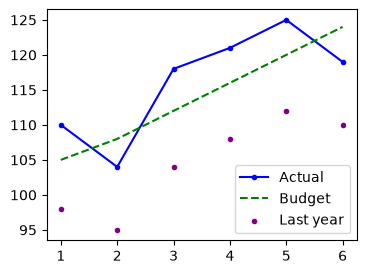

In [9]:
month = np.arange(1, 7)
actual = np.array([110, 104, 118, 121, 125, 119])      ### revenue in $K
budget = np.array([105, 108, 112, 116, 120, 124])
last_year = np.array([98, 95, 104, 108, 112, 110])

### MATLAB style line color and style
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(month, actual, 'b.-', label='Actual')    # blue line with dots
ax.plot(month, budget, 'g--', label='Budget')    # green dashed line

### .plot() parameters can also be specified in a more explicit way
ax.scatter(month, last_year, color='purple', marker='.', label='Last year')   # explicit parameters instead of a format string
ax.legend()
plt.show()

In [10]:
### Exercise: MATLAB-Style Color and Line Formatting
#   1. Create month = np.arange(1, 7),
#      store_a = np.array([62, 58, 66, 70, 73, 69]), and
#      store_b = np.array([48, 51, 47, 55, 58, 60]).
#   2. Use fig, ax = plt.subplots(figsize=(4, 3)).
#   3. Plot month vs store_a using 'b.-' (blue line with dots) and the label "Store A".
#   4. Plot month vs store_b using 'r--' (red dashed line) and the label "Store B".
#   5. Set the title to "Store A vs Store B" and show the legend.
### Your code starts here.




### Your code ends here.

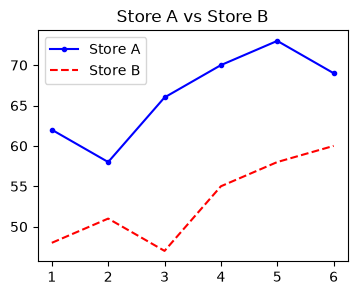

In [11]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

month = np.arange(1, 7)
store_a = np.array([62, 58, 66, 70, 73, 69])
store_b = np.array([48, 51, 47, 55, 58, 60])

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(month, store_a, 'b.-', label='Store A')
ax.plot(month, store_b, 'r--', label='Store B')
ax.set_title('Store A vs Store B')
ax.legend()
plt.show()


```{index} color (hex code), alpha (transparency)
```
#### The `color=` Parameter


You can define colors by name (`'blue'`) or by hex code (`'#8B008B'`). When a chart has several lines, give each a `label=` and show a legend, so the reader knows which line is which. Avoid pairing red with green: they are hard to tell apart for many color-blind readers.

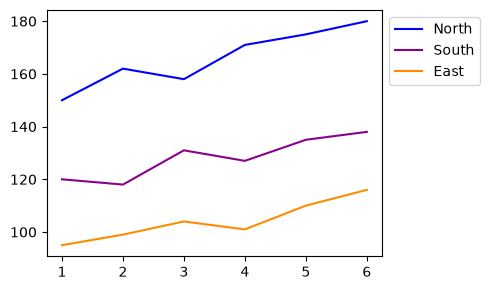

In [12]:
month = np.arange(1, 7)
north = np.array([150, 162, 158, 171, 175, 180])     ### revenue in $K
south = np.array([120, 118, 131, 127, 135, 138])
east = np.array([95, 99, 104, 101, 110, 116])

fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(month, north, color="blue", label="North")        ### color by name
ax.plot(month, south, color="#8B008B", label="South")     ### RGB hex code
ax.plot(month, east, color="#FF8C00", label="East")       ### RGB hex code
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))   ### just outside the top-right corner, clear of the lines
plt.tight_layout()
plt.show()

`alpha` sets transparency from 0 (invisible) to 1 (opaque). It matters when marks overlap: below, 300 orders are plotted by number of items. At full opacity, overlapping points hide each other; with `alpha=0.2`, darker areas show where many orders pile up.

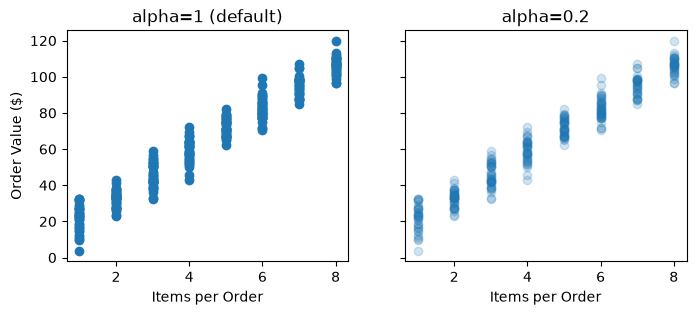

In [13]:
rng = np.random.default_rng(3)                        ### fixed seed: same numbers every run
items = rng.integers(1, 9, size=300)                  ### items per order
order_value = 10 + items * 12 + rng.normal(0, 6, size=300)   ### order value in $

fig, axes = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
axes[0].scatter(items, order_value)
axes[0].set_title('alpha=1 (default)')
axes[1].scatter(items, order_value, alpha=0.2)
axes[1].set_title('alpha=0.2')
for ax in axes:
    ax.set_xlabel('Items per Order')
axes[0].set_ylabel('Order Value ($)')
plt.show()

In [14]:
### Exercise: Colors with the color= Parameter and Alpha
#   1. Create month = np.arange(1, 7),
#      laptops = np.array([30, 34, 33, 38, 41, 45]),
#      phones = np.array([52, 50, 55, 58, 57, 62]), and
#      tablets = np.array([18, 20, 19, 23, 22, 25]).
#   2. Use fig, ax = plt.subplots(figsize=(4, 3)).
#   3. Plot month vs laptops with color="blue", alpha=0.3, and the label "Laptops".
#   4. Plot month vs phones with color="#228B22" (forest green), alpha=0.7, and the label "Phones".
#   5. Plot month vs tablets with color="tomato", alpha=1.0, and the label "Tablets".
#   6. Set the title to "Units Sold by Product" and show the legend.
### Your code starts here.




### Your code ends here.

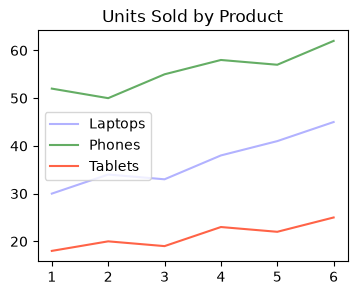

In [15]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

month = np.arange(1, 7)
laptops = np.array([30, 34, 33, 38, 41, 45])
phones = np.array([52, 50, 55, 58, 57, 62])
tablets = np.array([18, 20, 19, 23, 22, 25])

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(month, laptops, color='blue', alpha=0.3, label='Laptops')
ax.plot(month, phones, color='#228B22', alpha=0.7, label='Phones')
ax.plot(month, tablets, color='tomato', alpha=1.0, label='Tablets')
ax.set_title('Units Sold by Product')
ax.legend()
plt.show()

```{index} marker, line width
```
#### Line and Marker Styles


To change line width, use `linewidth` or `lw`. To change line style, use `linestyle` or `ls`. Marker shape, size, and colors can also be customized.


In [16]:
x = np.linspace(0, 5, 50)               ### simple numbers: this cell is a catalog of styles, not data

fig, ax = plt.subplots(figsize=(4, 3))

ax.plot(x, x+1, color="red", linewidth=0.25)
ax.plot(x, x+2, color="red", linewidth=0.50)
ax.plot(x, x+3, color="red", lw=1.00)
ax.plot(x, x+4, color="red", lw=2.00)

### possible linestyle options: '-', '--', '-.', ':', or 'None' (the default is '-'). 
ax.plot(x, x+5, color="green", lw=3, linestyle='-')
ax.plot(x, x+6, color="green", lw=3, ls='-.')
ax.plot(x, x+7, color="green", lw=3, ls=':')

### custom dash
line, = ax.plot(x, x+8, color="black", lw=1.50)
line.set_dashes([5, 10, 15, 10])        ### format: line length, space length, ...

### possible marker symbols: marker = '+', 'o', '*', 's', ',', '.', '1', '2', '3', '4', ...
ax.plot(x, x+ 9, color="blue", lw=3, ls='-', marker='+')
ax.plot(x, x+10, color="blue", lw=3, ls='--', marker='o')
ax.plot(x, x+11, color="blue", lw=3, ls='-', marker='s')
ax.plot(x, x+12, color="blue", lw=3, ls='--', marker='1')

### marker size and color
ax.plot(x, x+13, color="purple", lw=1, ls='-', marker='o', markersize=2)
ax.plot(x, x+14, color="purple", lw=1, ls='-', marker='o', markersize=4)
ax.plot(x, x+15, color="purple", lw=1, ls='-', marker='o', markersize=8, markerfacecolor="red")
ax.plot(x, x+16, color="purple", lw=1, ls='-', marker='s', markersize=8, 
        markerfacecolor="yellow", markeredgewidth=3, markeredgecolor="green");

In [17]:
### Exercise: Line Width, Style, and Markers
#   1. Create month = np.arange(1, 7),
#      actual = np.array([110, 104, 118, 121, 125, 119]),
#      budget = np.array([105, 108, 112, 116, 120, 124]), and
#      last_year = np.array([98, 95, 104, 108, 112, 110]).
#   2. Use fig, ax = plt.subplots(figsize=(4, 3)).
#   3. Plot month vs actual: color='red', lw=2, ls='-', marker='o', label='Actual'.
#   4. Plot month vs budget: color='gray', lw=1, ls='--', marker='s', label='Budget'.
#   5. Plot month vs last_year: color='blue', lw=3, ls=':', marker='^',
#      markersize=8, markerfacecolor='yellow', label='Last year'.
#   6. Set the title to "Actual, Budget, and Last Year" and show the legend.
### Your code starts here.




### Your code ends here.

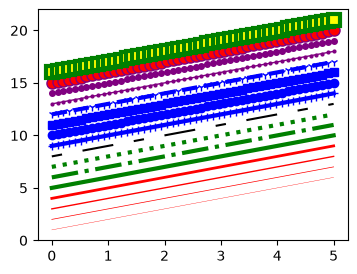

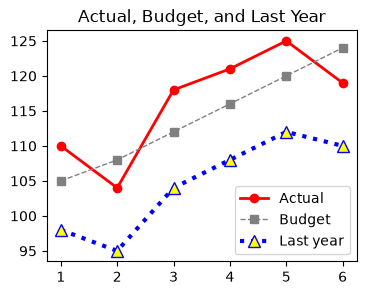

In [18]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

month = np.arange(1, 7)
actual = np.array([110, 104, 118, 121, 125, 119])
budget = np.array([105, 108, 112, 116, 120, 124])
last_year = np.array([98, 95, 104, 108, 112, 110])

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(month, actual, color='red', lw=2, ls='-', marker='o', label='Actual')
ax.plot(month, budget, color='gray', lw=1, ls='--', marker='s', label='Budget')
ax.plot(month, last_year, color='blue', lw=3, ls=':', marker='^', markersize=8, markerfacecolor='yellow', label='Last year')
ax.set_title('Actual, Budget, and Last Year')
ax.legend()
plt.show()

```{index} plot types
```
## Common Plot Types

So far we have used line plots to introduce Matplotlib. Below are a few common plot types, shown in the OO style so the examples stay consistent with the rest of the notebook.



```{index} scatter plot
```
### Scatter Plot

A **scatter plot** displays individual data points as dots on a two-dimensional plane, with one variable on the x-axis and another on the y-axis. Each dot represents a single observation. Scatter plots are useful for visualizing the relationship or correlation between two continuous variables, and for identifying patterns, clusters, or outliers in the data.


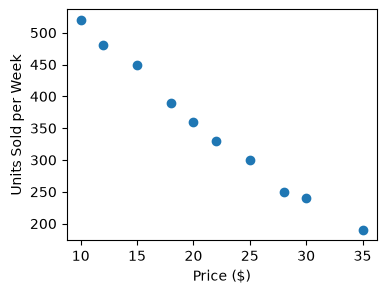

In [19]:
price = np.array([10, 12, 15, 18, 20, 22, 25, 28, 30, 35])     ### product price in $
units = np.array([520, 480, 450, 390, 360, 330, 300, 250, 240, 190])   ### units sold per week

fig, ax = plt.subplots(figsize=(4, 3))
ax.scatter(price, units)
ax.set_xlabel('Price ($)')
ax.set_ylabel('Units Sold per Week')
plt.show()

The points slope downward: at higher prices, the store sells fewer units each week. A scatter plot shows that two measures move together; on its own it does not prove that price causes the drop.


```{index} bar plot
```
### Bar Plot

A **bar plot** displays categorical data as rectangular bars, where the height (or length) of each bar is proportional to the value it represents. The x-axis typically shows the categories and the y-axis shows the corresponding values. Bar plots are useful for comparing quantities across distinct groups or categories.


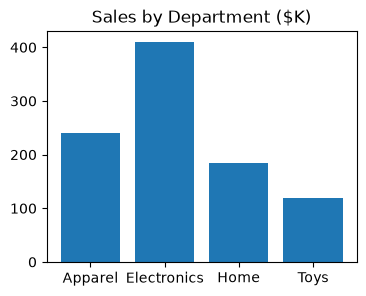

In [20]:
departments = ['Apparel', 'Electronics', 'Home', 'Toys']
sales = [240, 410, 185, 120]                   ### quarterly sales in $K

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(departments, sales)
ax.set_title('Sales by Department ($K)')
plt.show()

Electronics sells far more than the other departments. When the order of the categories has no meaning of its own, sort the bars from largest to smallest so the ranking is easy to read.


```{index} histogram, bin
```
### Histogram

A **histogram** displays the distribution of a continuous variable by dividing the data into bins (intervals) and counting how many values fall into each bin. The x-axis represents the value ranges, and the y-axis represents the frequency (count) of observations in each bin. Histograms are useful for visualizing the shape of a distribution — whether it is symmetric, skewed, or has multiple peaks.


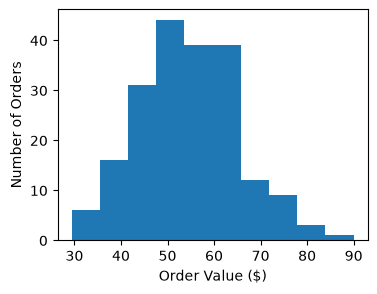

In [21]:
rng = np.random.default_rng(42)                        ### fixed seed: same numbers every run
order_values = rng.normal(loc=55, scale=12, size=200)  ### 200 online orders, in $

fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(order_values)
ax.set_xlabel('Order Value ($)')
ax.set_ylabel('Number of Orders')
plt.show()

Most orders fall between about \$40 and \$70, with fewer very small or very large orders. The number of **bins** changes what you see: too few bins hide the shape, and too many make it noisy. Try a few values:

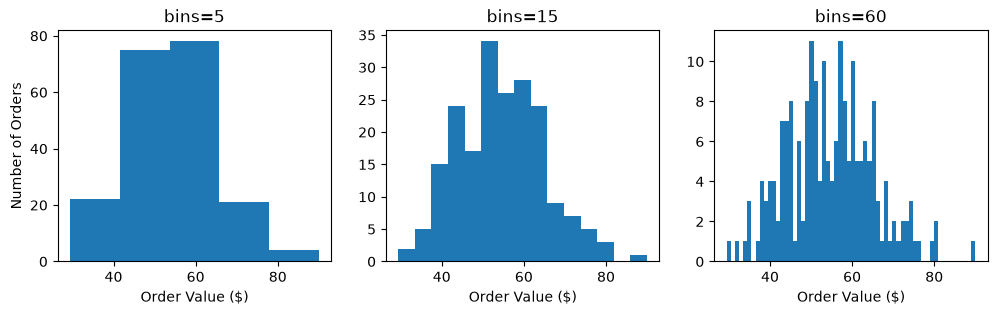

In [22]:
rng = np.random.default_rng(42)
order_values = rng.normal(loc=55, scale=12, size=200)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=False)
for ax, bins in zip(axes, [5, 15, 60]):
    ax.hist(order_values, bins=bins)
    ax.set_title(f'bins={bins}')
    ax.set_xlabel('Order Value ($)')
axes[0].set_ylabel('Number of Orders')
plt.show()

```{index} boxplot, interquartile range, outlier
```
### Boxplot

A **boxplot** (also called a box-and-whisker plot) summarizes a distribution in one compact shape:

- **The box** spans from the first quartile (Q1) to the third quartile (Q3), so it holds the middle 50% of the values. Its height is the **interquartile range** (IQR).
- **The line** inside the box marks the **median**.
- **The whiskers** reach the most extreme values that lie within 1.5 × IQR of the box.
- **Points beyond the whiskers** are plotted individually as **outliers**.

When there are no outliers, the whiskers reach the minimum and maximum. Boxplots are useful for comparing distributions across groups.

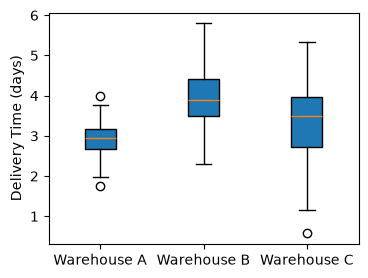

In [23]:
rng = np.random.default_rng(7)                         ### fixed seed: same numbers every run
### list comprehension to create delivery times (days) for three warehouses
delivery_days = [rng.normal(mean, sd, 100) for mean, sd in [(3.0, 0.5), (4.0, 0.8), (3.5, 0.9)]]

fig, ax = plt.subplots(figsize=(4, 3))

### rectangular box plot
ax.boxplot(delivery_days, patch_artist=True)
ax.set_xticks([1, 2, 3], ['Warehouse A', 'Warehouse B', 'Warehouse C'])
ax.set_ylabel('Delivery Time (days)')
plt.show()

Warehouse A is the fastest and most consistent. Warehouse B is the slowest, with a median near 4 days. Warehouse C sits in between on the median, but its tall box and long whiskers make it the least predictable, so a promised delivery date is hardest to keep there.

In [24]:
### Exercise: Visualizing Sales Data with Different Plot Types
#   The following data represent quarterly sales figures ($K) for four products
#   and daily website visits over 100 days.
#
#   products = ['Laptop', 'Phone', 'Tablet', 'Watch']
#   sales    = [320, 580, 140, 210]
#   visits   = np.random.default_rng(0).normal(loc=500, scale=80, size=100)
#
#   1. Create a figure with two side-by-side subplots: fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
#   2. On ax1, draw a bar chart of products vs. sales.
#      Set the title to "Quarterly Product Sales", x-label "Product", y-label "Sales ($K)".
#   3. On ax2, draw a histogram of visits using ax2.hist(visits, bins=15), 
#      color='orange', edgecolor='white', and alpha=0.7.
#      Set the title to "Daily Website Visits", x-label "Visits", y-label "Frequency".
#   4. Call plt.tight_layout() before displaying.
### Your code starts here.




### Your code ends here.

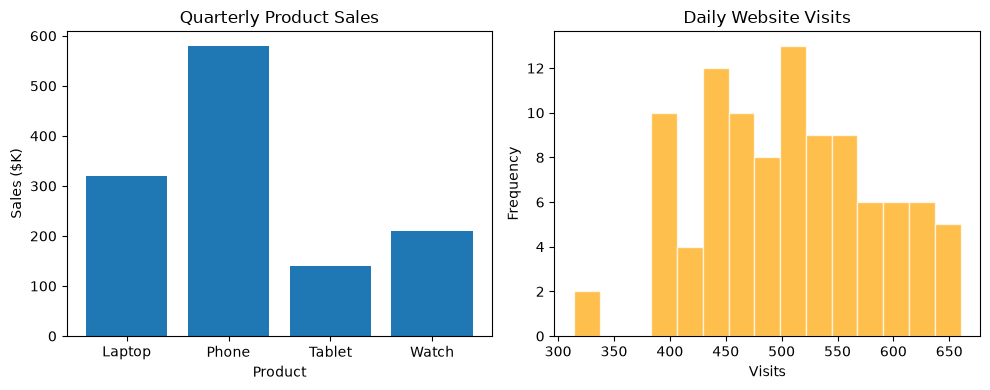

In [25]:
### Solution
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
products = ['Laptop', 'Phone', 'Tablet', 'Watch']
sales = [320, 580, 140, 210]
visits = rng.normal(loc=500, scale=80, size=100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(products, sales)
ax1.set_title('Quarterly Product Sales')
ax1.set_xlabel('Product')
ax1.set_ylabel('Sales ($K)')
ax2.hist(visits, bins=15, color='orange', edgecolor='white', alpha=0.7)
ax2.set_title('Daily Website Visits')
ax2.set_xlabel('Visits')
ax2.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## Summary

- Figure-level methods (`fig.suptitle()`, `fig.tight_layout()`, `fig.savefig()`) act on the whole figure; axes methods (`ax.set_title()`, `ax.set_xlim()`, `ax.legend()`, `ax.grid()`) act on one chart.
- `rcParams` and style sheets (`plt.style.use()`) change the defaults for every chart drawn afterward.
- Give each series a `label=` and call `ax.legend()`; use `loc=` to move the legend off the data.
- `ax.set_xlim()` and `ax.set_ylim()` zoom in on part of the data or start an axis at zero.
- Colors (names or hex codes), `alpha`, line style, line width, and markers make series easy to tell apart. A format string such as `'r--'` sets several of these at once.
- Match the plot type to the question: a line plot for a trend, a bar plot for comparing categories, a scatter plot for a relationship, and a histogram or boxplot for a distribution.

A practical way to choose among the main Matplotlib workflows is:

- Use `plt.plot()` for quick, one-off exploration.
- Use `plt.subplots()` for most plotting tasks.
- Use `fig.add_axes()` when you need manual placement or inset axes.

## Further Reading

- [Customizing Matplotlib with style sheets and rcParams](https://matplotlib.org/stable/users/explain/customizing.html): every default you can change, and how to make your own style.
- [Plot types](https://matplotlib.org/stable/plot_types/index.html): a one-page overview of the chart types Matplotlib can draw.
- [Examples gallery](https://matplotlib.org/stable/gallery/index.html): hundreds of charts with the code that made them.